# IMPORTING LIBRARIES

In [107]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
import os
import sklearn
from sklearn.cluster import KMeans # Here is where you import the k-means algorithm from scikit-learn.
import pylab as pl # PyLab is a convenience module that bulk imports matplotlib.

In [115]:
# Define the file path
path = r'C:\Users\rbhte\OneDrive\monami\data_immersion\Achievement 6'

# Correctly reading the pickle file
df = pd.read_pickle(os.path.join(path, 'Data', 'Prepared Data', 'df_revised.pkl'))

In [116]:
df.shape

(2055, 17)

In [117]:
num_unique_countries = df['Country name'].nunique()
print("Number of unique countries:", num_unique_countries)

Number of unique countries: 146


In [118]:
df.columns

Index(['Country name', 'year', 'Life Ladder', 'Log GDP per capita',
       'Social support', 'Healthy life expectancy at birth',
       'Freedom to make life choices', 'Generosity',
       'Perceptions of corruption', 'Positive affect', 'Negative affect',
       'Happiness Score', 'z_score', 'Happiness Category', 'Country Code',
       'IncomeGroup', '_merge'],
      dtype='object')

In [119]:
# Renaming columns
df = df.rename(columns={'year': 'Year', 'Happiness Score': 'Happiness score'})

In [120]:
# Drop the '_merge' column permanently
df.drop(columns=['_merge'], inplace=True)

# Cleaning, manipulations and renaming

In [163]:
# List of categorical columns to exclude
categorical_columns = ['Country name', 'Happiness Category', 'Country Code', 'IncomeGroup']

# Creating a subset without the categorical columns
df_s = df.drop(columns=categorical_columns)

# Displaying the subset
df_s.head(2)

,Year,Life Ladder,Log GDP per capita,Social support,Healthy life expectancy at birth,Freedom to make life choices,Generosity,Perceptions of corruption,Positive affect,Negative affect,Happiness score,z_score
0,2008,3.724,7.350,0.451,50.5,0.718,0.164,0.882,0.414,0.258,1.904222,-0.698756
1,2009,4.402,7.509,0.552,50.8,0.679,0.187,0.850,0.481,0.237,2.858711,-0.579692


In [164]:
df_s.columns

Index(['Year', 'Life Ladder', 'Log GDP per capita', 'Social support',
       'Healthy life expectancy at birth', 'Freedom to make life choices',
       'Generosity', 'Perceptions of corruption', 'Positive affect',
       'Negative affect', 'Happiness score', 'z_score'],
      dtype='object')

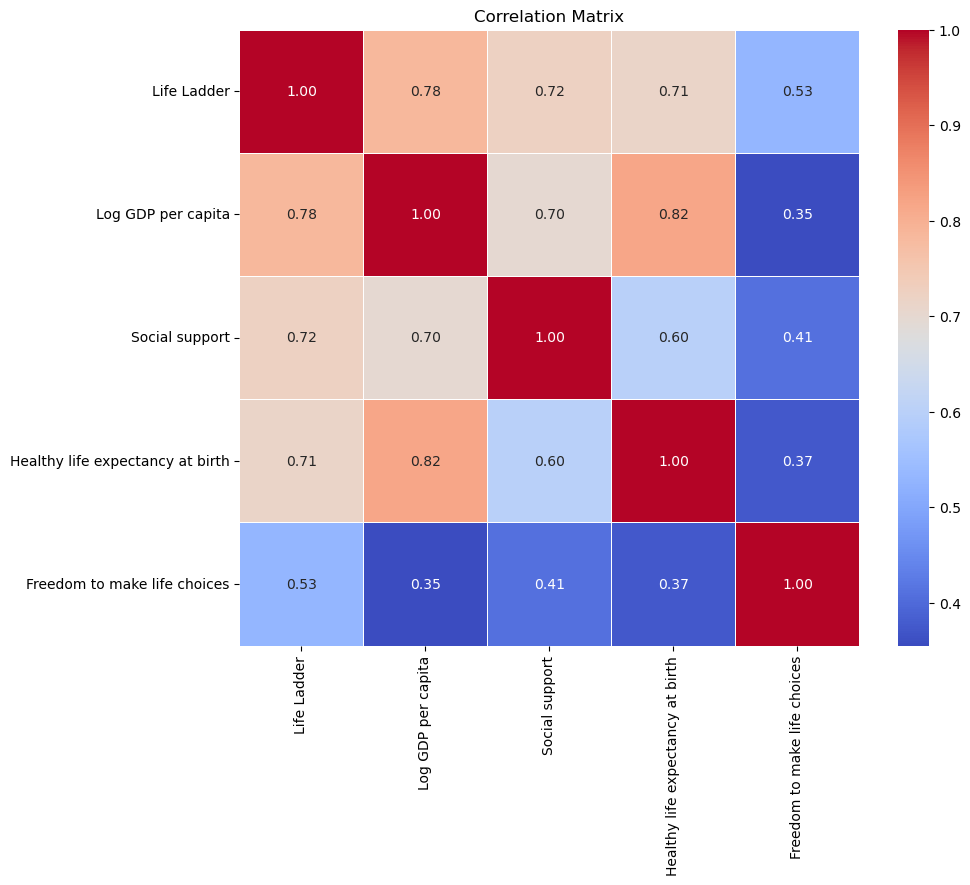

In [165]:
# Calculate the correlation matrix
correlation_matrix = df_s[numerical_columns].corr()

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()

# Identify columns with high correlation (>0.8) and consider removing them

# Standardize the data first

In [168]:
from sklearn.preprocessing import MinMaxScaler

# Define numerical columns to be scaled
numerical_columns = [
    'Life Ladder', 'Log GDP per capita', 'Social support',
    'Healthy life expectancy at birth', 'Freedom to make life choices'
]

# Apply MinMaxScaler
scaler = MinMaxScaler()
df_stan = scaler.fit_transform(df_s[numerical_columns])  # Scaling the selected columns

# Convert back to DataFrame with correct column names
df_stan = pd.DataFrame(df_minmax, columns=numerical_columns)

Have NOT used for Clustering (Less Relevant or Redundant)

Year → Not a meaningful clustering feature (clusters should be based on country characteristics, not time).

Happiness score → This is already a summary metric that combines other factors—using it for clustering can lead to circular reasoning.

z_score → A standardized score, likely derived from other variables. I have already standardized the dataset, so this is redundant.

In [171]:
df_stan.columns

Index(['Life Ladder', 'Log GDP per capita', 'Social support',
       'Healthy life expectancy at birth', 'Freedom to make life choices'],
      dtype='object')

In [172]:
print(df_stan.std())

Life Ladder                         0.168517
Log GDP per capita                  0.224549
Social support                      0.161466
Healthy life expectancy at birth    0.101886
Freedom to make life choices        0.182998
dtype: float64


# Use the elbow technique

In [173]:
df_stan. dtypes

Life Ladder                         float64
Log GDP per capita                  float64
Social support                      float64
Healthy life expectancy at birth    float64
Freedom to make life choices        float64
dtype: object

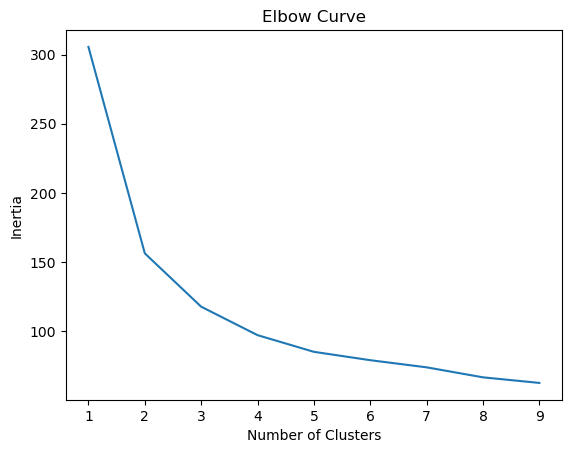

In [174]:
# Defines the range of potential clusters
num_cl = range(1, 10)

# Apply KMeans for each number of clusters and compute the inertia
inertia = [KMeans(n_clusters=i).fit(df_stan).inertia_ for i in num_cl]

# Plot the elbow curve
pl.plot(num_cl, inertia)
pl.xlabel('Number of Clusters')
pl.ylabel('Inertia')
pl.title('Elbow Curve')
pl.show()

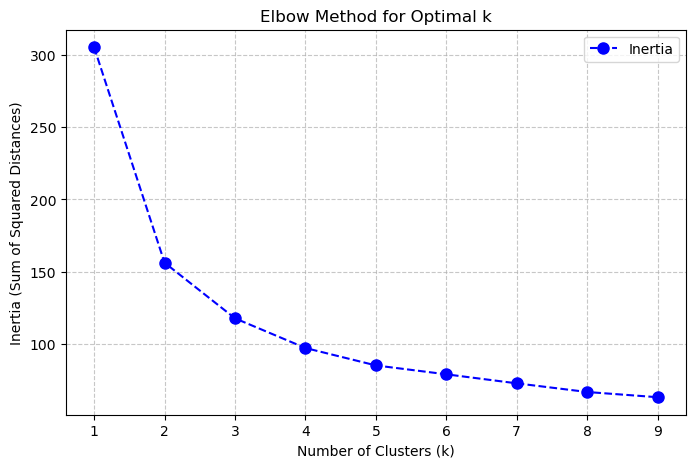

<Figure size 640x480 with 0 Axes>

In [175]:
import warnings

# Suppress warnings
warnings.filterwarnings("ignore", category=UserWarning)

# Defines the range of potential clusters
num_cl = range(1, 10)

# Apply KMeans for each number of clusters and compute the inertia
inertia = [KMeans(n_clusters=i).fit(df_stan).inertia_ for i in num_cl]


# Plot the Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(num_cl, inertia, marker='o', linestyle='--', color='b', markersize=8, label='Inertia')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (Sum of Squared Distances)')
plt.title('Elbow Method for Optimal k')
plt.xticks(num_cl)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

# Define the full save path and ensure the 'Visualisations' directory exists
save_path = os.path.join(r'C:\Users\rbhte\OneDrive\monami\data_immersion\Achievement 6', 'Visualisations', 'elbow_curve.png')

# Save the plot
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()


save_path1 = r'C:\Users\rbhte\elbow_curve.png'  # Save in a local folder
plt.savefig(save_path1, dpi=300, bbox_inches='tight')  # Save first
plt.show()  # Then show

In [176]:
print(os.path.exists(save_path))  # Should return True if saved correctly
print(os.path.exists(save_path1))  # Should return True if saved correctly

True
True


# Determining the Optimal Number of Clusters using the Elbow Method :

The Elbow Method is a popular technique to determine the optimal number of clusters (k) for k-means clustering.

Steps to Determine the Optimal Number of Clusters:

1. Plot the Elbow Curve : I have plotted the number of clusters (k) on the x-axis and inertia (how far the data points are from their centers) on the y-axis.
2. Look for the "Elbow": As I increase the number of clusters, inertia decreases, but at some point, it starts decreasing more slowly.
3. Identify the Optimal k: The "elbow" is where inertia levels off. This is where I’ll stop adding more clusters because adding more doesn’t improve the model much.
4. Choose the Optimal k: I’ll pick the number of clusters at the elbow, as it gives the best balance between simplicity and accuracy.

# Run the k-means algorithm : 
running the k-means algorithm means applying the k-means clustering method to your dataset to group the data points into k clusters 

In [177]:
# Verify the structure of the dataframe
print(type(df_stan))  # Check the type of df_stan
print(df_stan.shape)  # Check the shape of df_stan (should be 100 rows, N columns)

<class 'pandas.core.frame.DataFrame'>
(2055, 5)


In [178]:
df_stan.columns

Index(['Life Ladder', 'Log GDP per capita', 'Social support',
       'Healthy life expectancy at birth', 'Freedom to make life choices'],
      dtype='object')

In [179]:
print(df_stan.isnull().sum())  # Shows the count of NaN values per column

Life Ladder                         0
Log GDP per capita                  0
Social support                      0
Healthy life expectancy at birth    0
Freedom to make life choices        0
dtype: int64


In [180]:
# Create the k-means object and fit it to the standardized data
kmeans = KMeans(n_clusters=3)
df_stan['Clusters'] = kmeans.fit_predict(df_stan)

# Display the first few rows and value counts of the clusters
df_stan.head() 

,Life Ladder,Log GDP per capita,Social support,Healthy life expectancy at birth,Freedom to make life choices,Clusters
0,0.365172,0.146577,0.294584,0.644962,0.647292,2
1,0.466517,0.177944,0.428005,0.649381,0.595773,2
2,0.519731,0.198659,0.410832,0.653801,0.491413,2
3,0.381315,0.192148,0.387054,0.658220,0.354029,2
4,0.373991,0.207931,0.387054,0.662640,0.400264,2


In [181]:
df_stan['Clusters'].value_counts()

Clusters
1    767
0    733
2    555
Name: count, dtype: int64

In [182]:
# Display the updated dataframe
print(df_stan.head(1))

   Life Ladder  Log GDP per capita  Social support  \
0     0.365172            0.146577        0.294584   

   Healthy life expectancy at birth  Freedom to make life choices  Clusters  
0                          0.644962                      0.647292         2  


# Scatterplots using the clustered data

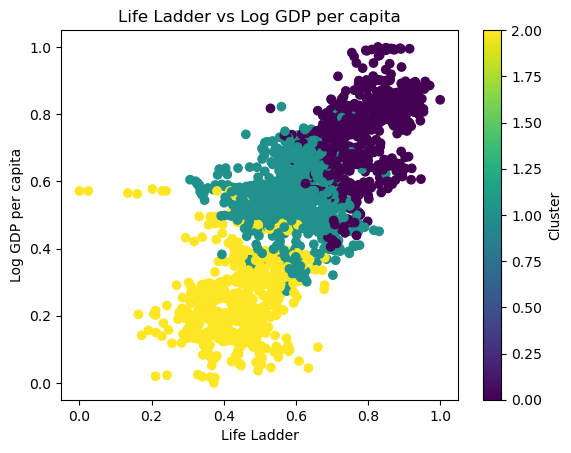

In [184]:
# Scatter plot of 'Life Ladder' vs 'Log GDP per capita', colored by 'Clusters'
plt.scatter(df_stan['Life Ladder'], df_stan['Log GDP per capita'], c=df_stan['Clusters'], cmap='viridis')
plt.xlabel('Life Ladder')
plt.ylabel('Log GDP per capita')
plt.title('Life Ladder vs Log GDP per capita')
plt.colorbar(label='Cluster')
plt.show()

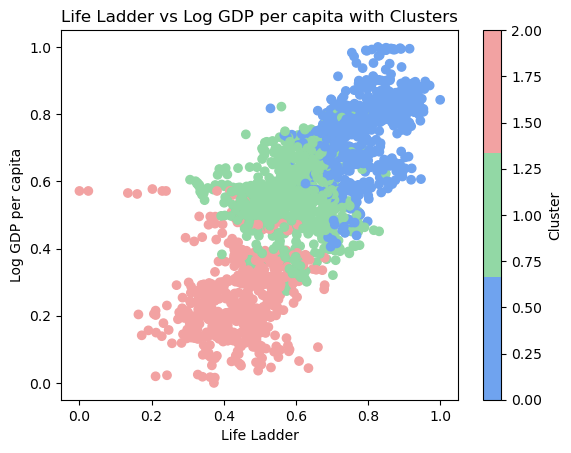

In [186]:
from matplotlib.colors import ListedColormap

# Define the full save path and ensure the 'Visualisations' directory exists
save_path = os.path.join(r'C:\Users\rbhte\OneDrive\monami\data_immersion\Achievement 6', 'Visualisations', 'cluster_scatter_plot_colored.png')

# Create the directory if it doesn't exist
os.makedirs(os.path.dirname(save_path), exist_ok=True)

# Define a custom, muted color palette for the clusters
cmap = ListedColormap(['#6fa3ef', '#92d8a5', '#f2a2a2'])  # Softer colors

# Scatter plot of 'Life Ladder' vs 'Log GDP per capita', with custom colors for each cluster
plt.scatter(df_stan['Life Ladder'], df_stan['Log GDP per capita'], c=df_stan['Clusters'], cmap=cmap)
plt.xlabel('Life Ladder')
plt.ylabel('Log GDP per capita')
plt.title('Life Ladder vs Log GDP per capita with Clusters')

# Add a color bar to show which cluster corresponds to which color
plt.colorbar(label='Cluster')

# Save the plot
plt.savefig(save_path, dpi=300, bbox_inches='tight')

# Show the plot
plt.show()

- **Clusters are close together** : This suggests the data might not have enough distinct patterns, or the features are not well-suited for clustering.
- **Possibly too few clusters** : The choice of 3 clusters might not be optimal. Experimenting with more clusters could yield better separation.
- **Feature set limitations** : The current features might not effectively differentiate between groups. 

# Barplot of the 'Mean Social support' for Each Cluster

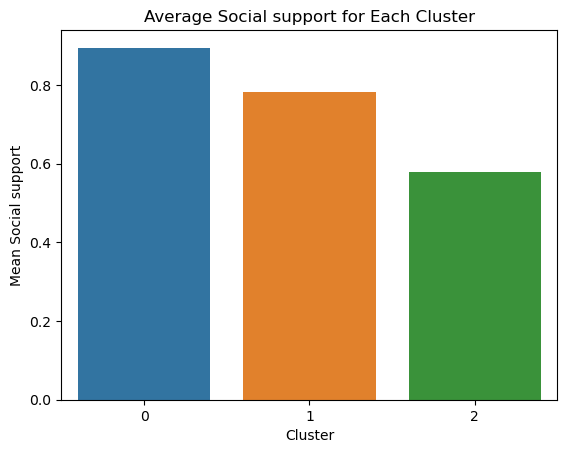

In [196]:
# Define custom colors for each cluster
custom_palette = ['#1f77b4', '#ff7f0e', '#2ca02c']

# Create the barplot with custom colors
sns.barplot(x='Clusters', y='Social support', data=df_stan, estimator='mean', errorbar=None, hue='Clusters', palette=custom_palette, legend=False)

# Set labels and title
plt.xlabel('Cluster')
plt.ylabel('Mean Social support')
plt.title('Average Social support for Each Cluster')

# Define the save path for the plot
save_path = os.path.join(r'C:\Users\rbhte\OneDrive\monami\data_immersion\Achievement 6', 'Visualisations', 'average_life_ladder_by_cluster.png')

# Save the plot
plt.savefig(save_path, dpi=300, bbox_inches='tight')

# Show the plot
plt.show()

# Violin plot of "Freedom to Make Life Choices" by "Cluster"

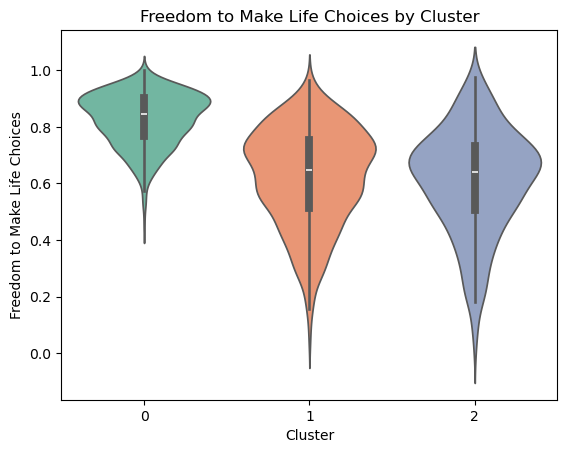

In [194]:
# Use a vibrant color palette (Set2)
custom_palette_violin = sns.color_palette("Set2", n_colors=3)  # Set2 palette with 3 distinct colors

# Create the violin plot for 'Freedom to Make Life Choices' by 'Cluster'
sns.violinplot(x='Clusters', y='Freedom to make life choices', data=df_stan, hue='Clusters', palette=custom_palette_violin, legend=False)

# Set labels and title
plt.xlabel('Cluster')
plt.ylabel('Freedom to Make Life Choices')
plt.title('Freedom to Make Life Choices by Cluster')

# Define the save path for the plot
save_path = os.path.join(r'C:\Users\rbhte\OneDrive\monami\data_immersion\Achievement 6', 'Visualisations', 'freedom_to_make_life_choices_by_cluster.png')

# Save the plot
plt.savefig(save_path, dpi=300, bbox_inches='tight')

# Show the plot
plt.show()

# Descriptive statistics for the Clusters

In [187]:
# Calculate descriptive statistics for each cluster
cluster_stats = df_stan.groupby('Clusters').describe()

# Display the results
print(cluster_stats)

         Life Ladder                                                    \
               count      mean       std       min       25%       50%   
Clusters                                                                 
0              733.0  0.800658  0.084560  0.529596  0.735575  0.799103   
1              767.0  0.598127  0.091997  0.306577  0.540807  0.601196   
2              555.0  0.443306  0.096368  0.000000  0.379671  0.452616   

                             Log GDP per capita            ...  \
               75%       max              count      mean  ...   
Clusters                                                   ...   
0         0.871450  1.000000              733.0  0.762824  ...   
1         0.665620  0.849327              767.0  0.557435  ...   
2         0.504335  0.680120              555.0  0.258412  ...   

         Healthy life expectancy at birth            \
                                      75%       max   
Clusters                                        

# KEY FINDINGS



Cluster 0 (Highest Life Ladder & Freedom to Make Life Choices) :

This cluster has the highest mean values for Life Ladder (0.80) and Freedom to make life choices (0.83), indicating that it consists of individuals who are the most satisfied with life and have the greatest freedom.

These individuals also have higher Log GDP per capita and Healthy life expectancy, suggesting better economic and health conditions.

Cluster 1 (Moderate Satisfaction and Freedom) :

Cluster 1 shows lower life satisfaction (mean 0.60) and freedom (mean 0.62), but still better than Cluster 2.

The economic status (Log GDP per capita) is moderate compared to Cluster 0, and the health metrics are also decent.

Cluster 2 (Lowest Life Ladder & Freedom) :

This group has the lowest life satisfaction (mean 0.44) and the lowest freedom (mean 0.61). These individuals may face significant socio-economic and health challenges.

The Log GDP per capita is also significantly lower in Cluster 2, indicating poorer economic conditions.

# FUTURE USES OF THESE RESULTS

TARGETED INTERVENTIONS:

The clusters reveal socio-economic and health disparities that can guide targeted policies or interventions. For example, Cluster 2 might benefit from social welfare programs or health initiatives.

SEGMENTATION FOR BUSINESS OR MARKETING:

Understanding the characteristics of each cluster helps businesses target different customer groups more effectively based on life satisfaction, economic conditions, or health status.

PREDICTIVE MODELING:

These cluster characteristics can serve as input for predictive models, helping to anticipate trends or behavior patterns based on socio-economic and health features.

# Export the df_stan dataframe

In [197]:
# Define the path for saving the pickle file
save_path3 = os.path.join(r'C:\Users\rbhte\OneDrive\monami\data_immersion\Achievement 6', 'Data', 'Prepared Data', 'df_remodified.pkl')

# Export the dataframe as a pickle file
df_stan.to_pickle(save_path3)

# Confirm the file is saved
print(f"File saved as: {save_path3}")

File saved as: C:\Users\rbhte\OneDrive\monami\data_immersion\Achievement 6\Data\Prepared Data\df_remodified.pkl
